<a href="https://colab.research.google.com/github/nittasamith1/intelligent-credit-card-fraud-detection/blob/main/CreditCardFraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Required Libraries**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import SMOTE   # optional balancing

**Load the Dataset**

In [5]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (23858, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


**Data Cleaning**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Checking Missing Values

In [8]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


Remove Duplicates

In [9]:
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)


After removing duplicates: (23770, 31)


**Feature Scaling**

In [15]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])


**Data** **Integration**

In [11]:
print("Data Integration: Not required (single dataset).")


Data Integration: Not required (single dataset).


**Prepare Training and Test Data**

Separate features and target

In [16]:
X = df.drop("Class", axis=1)
y = df["Class"]

Train-Test Split

In [18]:
# Drop rows with missing target values
df = df.dropna(subset=["Class"])

# Now separate
X = df.drop("Class", axis=1)
y = df["Class"]

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (19015, 30)
Testing shape: (4754, 30)


**Train Random Forest Model**

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:,1]

**Evaluate Model Performance**

Recall and Other Evaluation Metrics

In [21]:
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Recall:", recall)
print("Precision:", precision)
print("F1-Score:", f1)
print("ROC-AUC Score:", roc_auc)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Recall: 0.8333333333333334
Precision: 0.9375
F1-Score: 0.8823529411764706
ROC-AUC Score: 0.9711312875375376

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4736
         1.0       0.94      0.83      0.88        18

    accuracy                           1.00      4754
   macro avg       0.97      0.92      0.94      4754
weighted avg       1.00      1.00      1.00      4754



**Visualize ROC Curve**

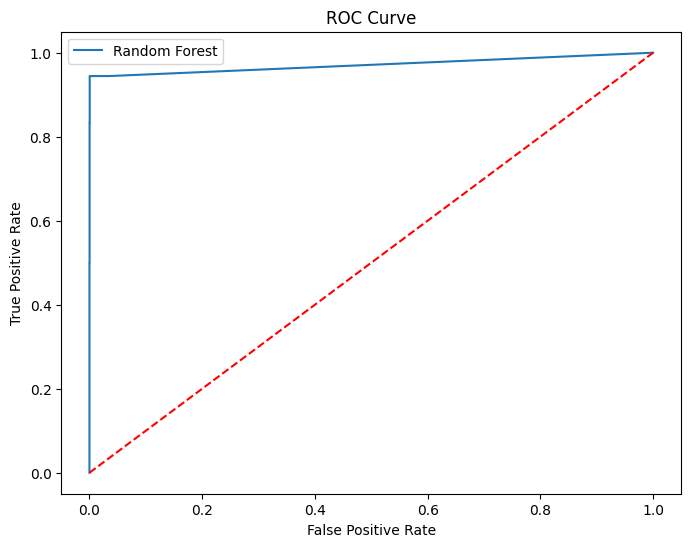

In [22]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Confusion Matrix Heatmap**

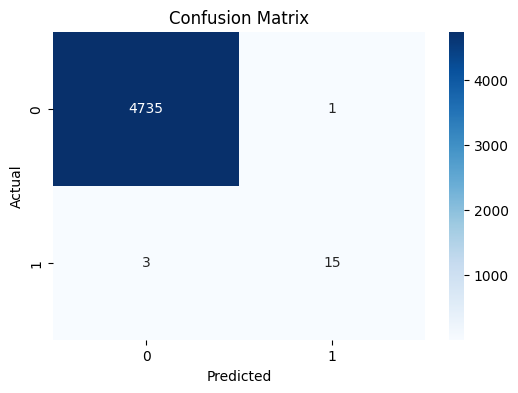

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Balance Data With SMOTE**

In [24]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

rf_sm = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf_sm.fit(X_train_sm, y_train_sm)

y_pred_sm = rf_sm.predict(X_test)
print("SMOTE Recall:", recall_score(y_test, y_pred_sm))
print("SMOTE ROC-AUC:", roc_auc_score(y_test, rf_sm.predict_proba(X_test)[:,1]))

SMOTE Recall: 0.9444444444444444
SMOTE ROC-AUC: 0.9698643956456456
